# Telco Churn Analysis Project

In [66]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [67]:
import warnings
warnings.filterwarnings('ignore')

In [68]:
df = pd.read_csv('Customer Churn.csv')

In [69]:
pd.set_option('display.max_columns',None)
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [71]:
df.duplicated().sum()

np.int64(0)

In [72]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [73]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [74]:
df['TotalCharges'].fillna(0,inplace=True)

In [75]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [77]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [78]:
gender_wise_churn = df.groupby(['gender','Churn'],as_index=False).size()
gender_wise_churn

,gender,Churn,size
0,Female,No,2549
1,Female,Yes,939
2,Male,No,2625
3,Male,Yes,930


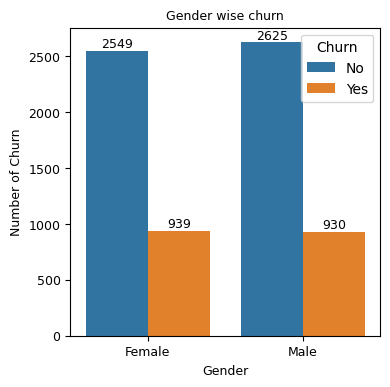

In [79]:
plt.figure(figsize=(4,4))
ax = sns.barplot(data=gender_wise_churn, x='gender',y='size',hue='Churn')

for bars in ax.containers:
    ax.bar_label(bars, fontsize=9)

ax.tick_params(axis='x',labelsize=9)
ax.tick_params(axis='y',labelsize=9)
plt.title('Gender wise churn',fontsize=9)
plt.ylabel("Number of Churn",fontsize=9)
plt.xlabel("Gender",fontsize=9)
plt.show()

#Churn distribution is almost identical across genders, indicating that gender does not significantly impact customer churn.

In [80]:
SCE = {0:"Not Senior Citizen",1:"Senior Citizen"}
df['SCEncoding'] = df['SeniorCitizen'].map(SCE)

In [81]:
df = df[['customerID', 'gender', 'SeniorCitizen', 'SCEncoding', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn']]
df.head(2)

,customerID,gender,SeniorCitizen,SCEncoding,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Not Senior Citizen,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,Not Senior Citizen,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [82]:
SC_wise_churn = df.groupby(['SCEncoding','Churn'],as_index=False).size()
SC_wise_churn

,SCEncoding,Churn,size
0,Not Senior Citizen,No,4508
1,Not Senior Citizen,Yes,1393
2,Senior Citizen,No,666
3,Senior Citizen,Yes,476


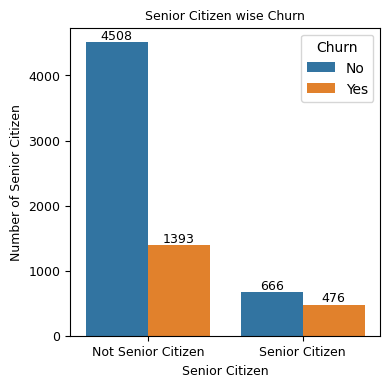

In [83]:
plt.figure(figsize=(4,4))
ax = sns.barplot(data=SC_wise_churn, x='SCEncoding',y='size', hue='Churn')

for bars in ax.containers:
    ax.bar_label(bars, fontsize=9)

ax.tick_params(axis='x',labelsize=9)
ax.tick_params(axis='y',labelsize=9)


plt.title('Senior Citizen wise Churn',fontsize=9)
plt.ylabel('Number of Senior Citizen',fontsize=9)
plt.xlabel('Senior Citizen',fontsize=9)
plt.show()

#Senior citizens exhibit a noticeably higher churn rate compared to non-senior customers, despite representing a smaller portion of the total customer base.

In [84]:
df.head(2)

,customerID,gender,SeniorCitizen,SCEncoding,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Not Senior Citizen,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,Not Senior Citizen,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [85]:
(df['tenure'].min(),df['tenure'].max())

(0, 72)

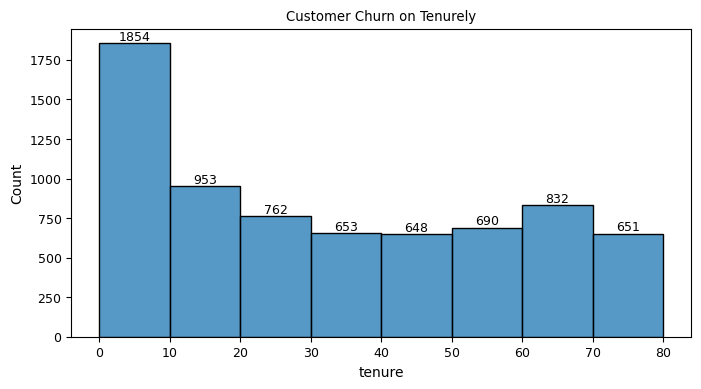

In [86]:
plt.figure(figsize=(8,4))
ax = sns.histplot(data=df['tenure'],bins=[0,10,20,30,40,50,60,70,80])

for bars in ax.containers:
    ax.bar_label(bars,fontsize=9)

ax.tick_params(axis='x',labelsize=9)
ax.tick_params(axis='y',labelsize=9)
plt.title('Customer Churn on Tenurely',fontsize=9.5)
plt.show()

#Customer churn is significantly higher among customers with lower tenure, indicating that new customers are more likely to leave compared to long-term customers.

In [87]:
df.head(2)

,customerID,gender,SeniorCitizen,SCEncoding,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Not Senior Citizen,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,Not Senior Citizen,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [88]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'SCEncoding', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'], dtype=object)

In [89]:
services = ['PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies']

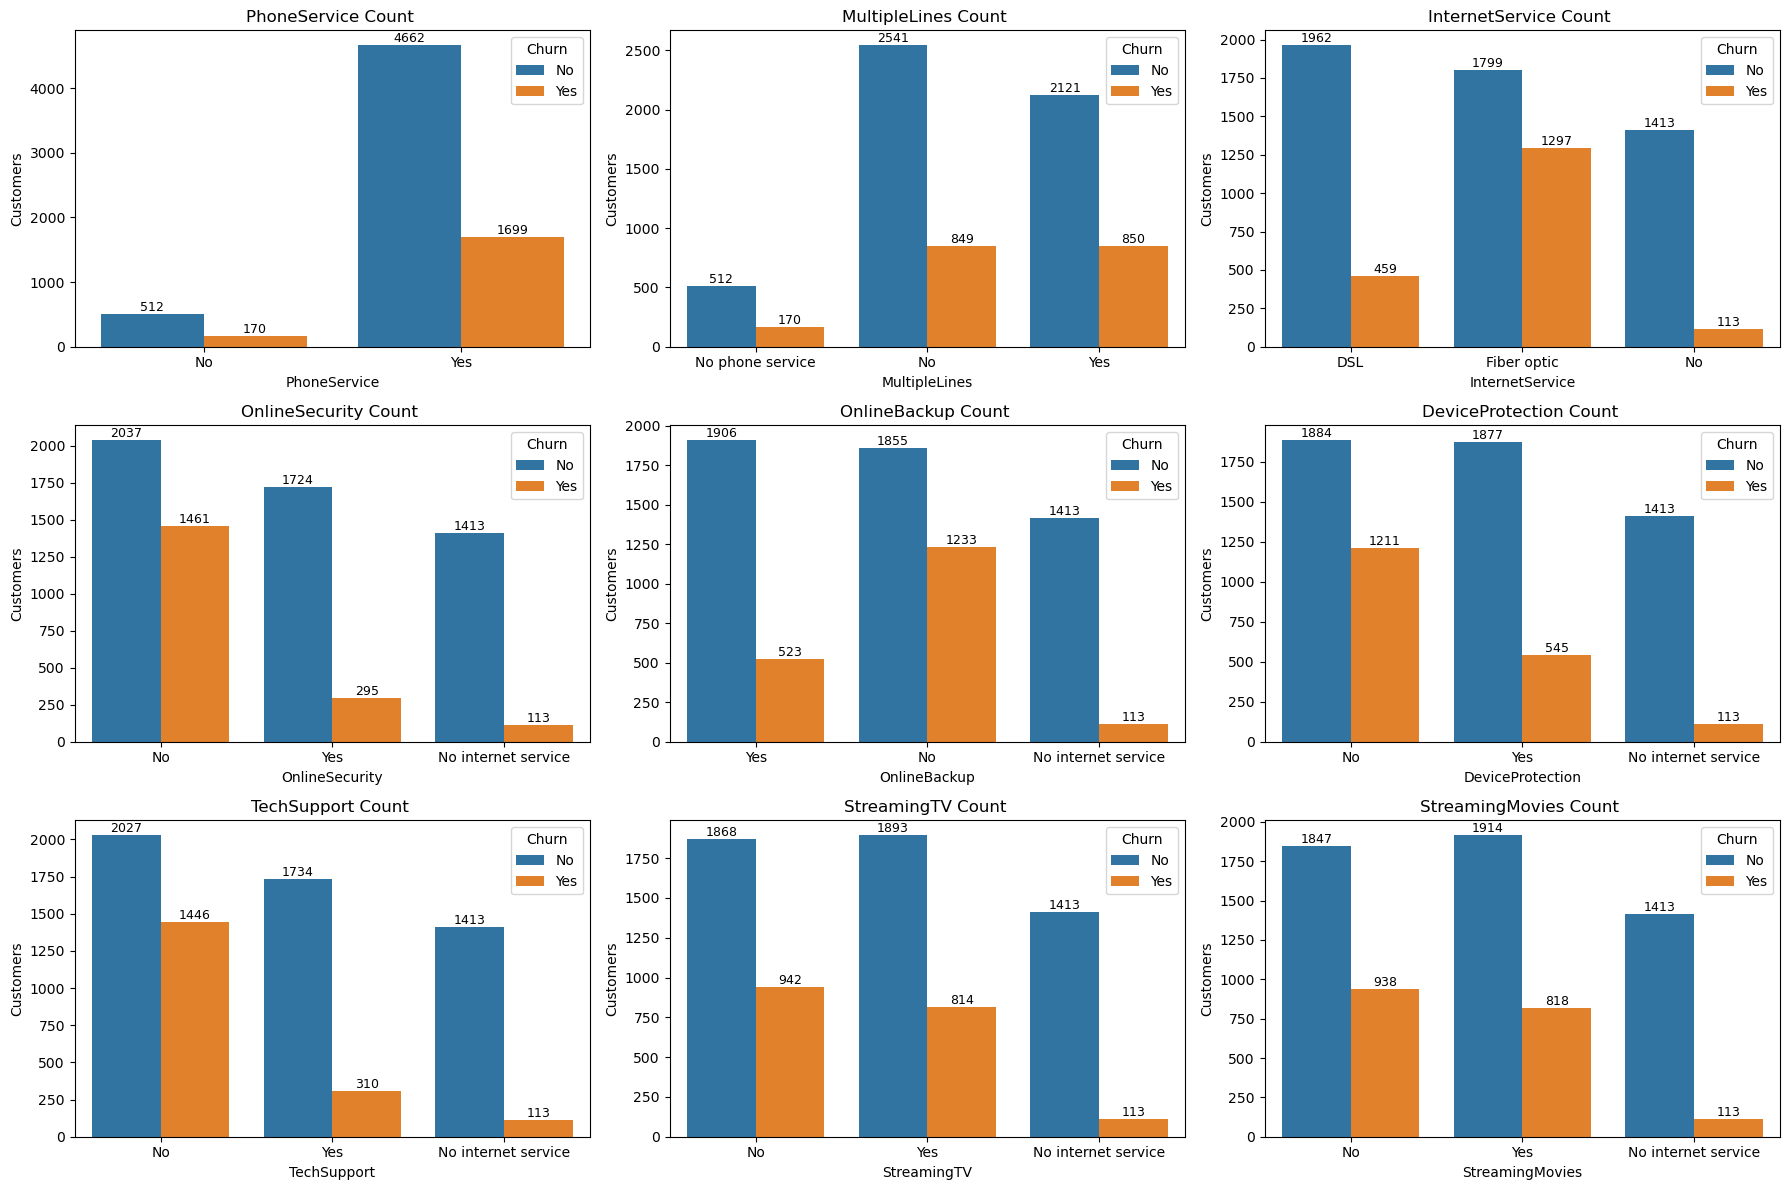

In [90]:
fig,axes = plt.subplots(3,3,figsize=(18,12))

axes = axes.flatten()

for idx, col in enumerate(services):
    ax = sns.countplot(data=df, x=col, ax=axes[idx],hue='Churn')

    for bars in ax.containers:
        ax.bar_label(bars,fontsize=(9))
    ax.set_title(f"{col} Count ")
    ax.set_ylabel("Customers")

plt.tight_layout()
plt.show()

#Customers without Online Security have significantly higher churn compared to those who have it.

#Lack of Tech Support is strongly associated with increased churn.

#Customers without Online Backup also show higher churn behavior.

#Fiber optic Internet users have a noticeably higher churn rate compared to DSL users.

#Services like PhoneService and MultipleLines show relatively less impact on churn.

#Customers with No Internet Service generally have lower churn counts.

#Value-added services (Security, Support, Backup) appear to play a crucial role in customer retention.

In [91]:
df.head(2)

,customerID,gender,SeniorCitizen,SCEncoding,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Not Senior Citizen,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,Not Senior Citizen,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [92]:
Contract_wise_churn = df.groupby(['Contract','Churn']).size().unstack()
Contract_wise_churn

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [93]:
Contract_wise_churn_per = Contract_wise_churn.div(Contract_wise_churn.sum(axis=1),axis=0) * 100
Contract_wise_churn_per

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


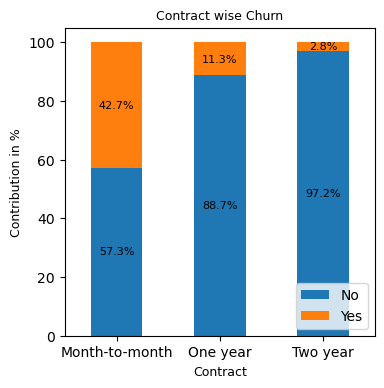

In [94]:
ax = Contract_wise_churn_per.plot(kind='bar',stacked=True,figsize=(4,4))

for idx, contract in enumerate(Contract_wise_churn_per.index):
    total=0
    for status in Contract_wise_churn_per.columns:
        value = Contract_wise_churn_per.loc[contract, status]

        if value > 0:
            ax.text(idx, total+(value/2), f"{value:.1f}%", ha='center', va='center',fontsize=8)

        total+=value

ax.tick_params(axis='x',rotation=0)
plt.legend(loc='lower right')

plt.title('Contract wise Churn',fontsize=9)
plt.ylabel('Contribution in %',fontsize=9)
plt.xlabel('Contract',fontsize=9)
plt.show()

#Customers on month-to-month contracts have the highest churn rate (42.7%), indicating lower retention and potential dissatisfaction or lack of commitment.

#As contract length increases, churn drops significantly: 11.3% for one-year contracts and only 2.8% for two-year contracts.

#The majority of customers in longer contracts (one-year and two-year) are retained (88.7% and 97.2% respectively).

In [95]:
df.head(2)

,customerID,gender,SeniorCitizen,SCEncoding,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Not Senior Citizen,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,Not Senior Citizen,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [96]:
PaymentMethod_wise_churn = df.groupby(['PaymentMethod','Churn'],as_index=False).size()
PaymentMethod_wise_churn

,PaymentMethod,Churn,size
0,Bank transfer (automatic),No,1286
1,Bank transfer (automatic),Yes,258
2,Credit card (automatic),No,1290
3,Credit card (automatic),Yes,232
4,Electronic check,No,1294
5,Electronic check,Yes,1071
6,Mailed check,No,1304
7,Mailed check,Yes,308


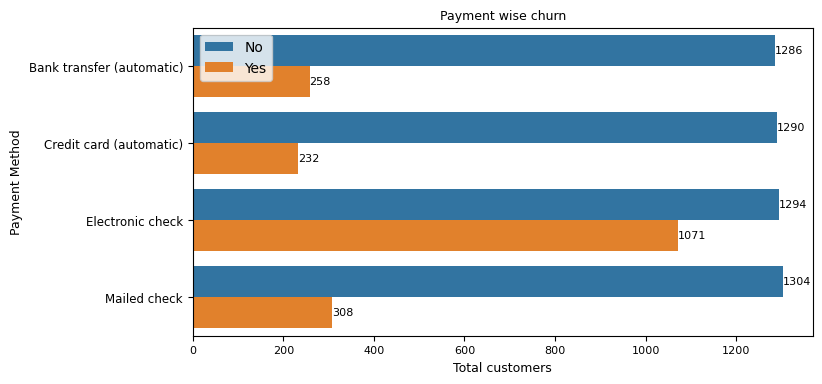

In [97]:
plt.figure(figsize=(8,4))
ax = sns.barplot(data=PaymentMethod_wise_churn, y='PaymentMethod',x='size',hue='Churn')

for bars in ax.containers:
    ax.bar_label(bars, fontsize=8)

ax.tick_params(axis='x',labelsize=8)
ax.tick_params(axis='y',labelsize=8.5)

plt.title('Payment wise churn',fontsize=9)
plt.ylabel("Payment Method",fontsize=9)
plt.xlabel("Total customers",fontsize=9)
plt.legend(loc='upper left')
plt.show()

#Customers using (electronic checks and Mailed checks) to show the highest churn rate at 80.9%, while those with automatic payment methods like (bank transfer and credit card) are far more likely to stay, with churn rates below 20%.

In [98]:
df.head(2)

,customerID,gender,SeniorCitizen,SCEncoding,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Not Senior Citizen,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,Not Senior Citizen,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


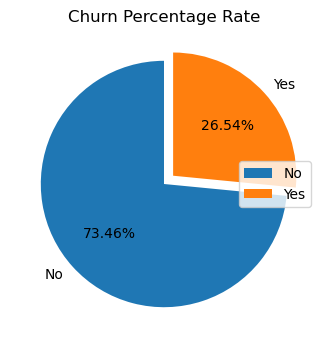

In [103]:
exp = [0,0.1]
churnCount = df['Churn'].value_counts(normalize=True) * 100

churnCount.plot(kind='pie',autopct="%1.2f%%", explode=exp, startangle=90, figsize=(4,4))

plt.title('Churn Percentage Rate')
plt.ylabel('')
plt.legend(loc='center right')
plt.show()

#26.54% of customers have churned, while the majority (73.46%) remain active.This indicates that roughly one highlighting a significant retention challenge.